<a href="https://colab.research.google.com/github/chaika-jonathan-livingston/-my-first-devops-repo/blob/master/%D0%9F%D1%80%D0%B0%D0%BA%D1%82%D0%B8%D0%BA%D0%B0_%D0%98%D0%98_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder
from sklearn.preprocessing import RobustScaler
from sklearn.preprocessing import TargetEncoder
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.dummy import DummyRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from optuna.samplers import TPESampler

In [ ]:
!pip install optuna
import optuna

import warnings
warnings.filterwarnings('ignore')
from google.colab import drive
drive.mount('/content/drive')
!pip install kaggle --upgrade
import os
os.environ['KAGGLE_CONFIG_DIR'] = '/content/drive/MyDrive/kaggle'
!kaggle datasets download -d egorkainov/moscow-housing-price-dataset
!unzip moscow-housing-price-dataset.zip -d moscow-housing-price_dataset

In [ ]:
df = pd.read_csv('moscow-housing-price_dataset/data.csv')
print('Размер датасета: ', df.shape, end = "\n")
print(df.head(), end = "\n")
print("Пустые значения: ", df.columns.isna(), '\n')

num_cols = df.select_dtypes(exclude='object')
print("\nРазмер цифровых признаков: ", num_cols.shape)
print(num_cols.describe())
fig, axes = plt.subplots(4, 2, figsize=(15, 15))
sns.histplot(df['Price'], bins=50, color='r', ax=axes[0, 0])
sns.histplot(df['Minutes to metro'], bins=50, color='g', ax=axes[0, 1])
sns.histplot(df['Number of rooms'], bins=50, color='b', ax=axes[1, 0])
sns.histplot(df['Area'], bins=50, color='m', ax=axes[1, 1])
sns.histplot(df['Living area'], bins=50, color='y', ax=axes[2, 0])
sns.histplot(df['Kitchen area'], bins=50, color='g', ax=axes[2, 1])
sns.histplot(df['Floor'], bins=50, color='b', ax=axes[3, 0])
sns.histplot(df['Number of floors'].dropna(), bins=50, color='m', ax=axes[3, 1])
scaler = RobustScaler()
df[['Area', 'Living area', 'Kitchen area']] = scaler.fit_transform(
    df[['Area', 'Living area', 'Kitchen area']])

In [ ]:
print('\nПочему в станциях метро есть дубликаты?')
cat_cols = df.select_dtypes(include='object')
cat_cols.describe()
stations = df['Metro station'].str.lower().unique().tolist()
low_stations = df['Metro station'].str.lower().str.strip().unique().tolist()
difference = set(stations) - set(low_stations)
print('Пример дубликатов: ', sorted(list(difference)))
df['Metro station'] = df['Metro station'].str.lower().str.strip()
print("Новое количество уникальных станций: ", df['Metro station'].nunique())

cat_features = ['Apartment type', 'Region', 'Renovation']
encoder = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
df[cat_features] = encoder.fit_transform(df[cat_features])
print("Теперь тренировочная выборка выглядит так: ", df.head())
print(df['Renovation'].unique())

num_cols = df.select_dtypes(exclude='object')
corrs = num_cols.corr()
upper_tri = corrs.where(np.triu(np.ones(corrs.shape), k=1).astype(np.bool))
plt.figure(figsize=(10, 10))
sns.heatmap(upper_tri, cmap="RdYlBu_r", square=True, annot=True);

In [ ]:
cols_to_drop = ['Minutes to metro', 'Region', 'Number of floors', 'Living area']
df = df.drop(columns=cols_to_drop)
print('\nТренировная выборка после удаления некритичных признаков: ', df.head())

У меня задача регрессии, так как моя целевая переменная (стоимость квартиры) - вещественное число. Датасет - это обучающая выборка, где по ряду признаков уже определена стоимость квартиры.
Создадим алгоритм а(Х) = У.

Метрики - это части функционала качества, измеряющего качество построения алгоритма. В нашем случае лучше выбрать среднюю абсолютную ошибку MAE, потому что она менее чувствительна к выбросам и более наглядно будет показывать преимущества одной модели относительно другой.
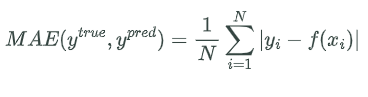

Также возьмем коэффициент детерминации R**2.
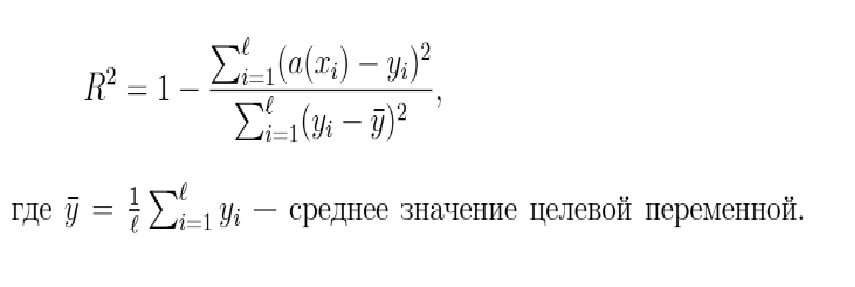

In [ ]:
X = df.drop('Price', axis=1)
y = df['Price']
y = scaler.fit_transform(df[['Price']])
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.1, random_state=42)
print(f"Train size: {X_train.shape}")
print(f"Validation size: {X_val.shape}")
print(f"Test size: {X_test.shape}")

In [ ]:
encoder = TargetEncoder(target_type='continuous', smooth='auto', random_state=42)
X_train_encoded = X_train.copy()
X_train_encoded['Metro station'] = encoder.fit_transform(X_train[['Metro station']], y_train)
X_val_encoded = X_val.copy()
X_val_encoded['Metro station'] = encoder.transform(X_val[['Metro station']])
X_test_encoded = X_test.copy()
X_test_encoded['Metro station'] = encoder.transform(X_test[['Metro station']])

# freq_map = X_train['Metro station'].value_counts().to_dict()
# X_train_encoded = X_train.copy()
# X_train_encoded['Metro station'] = X_train['Metro station'].map(freq_map).fillna(0)
# X_val_encoded = X_val.copy()
# X_val_encoded['Metro station'] = X_val['Metro station'].map(freq_map).fillna(0)
# X_test_encoded = X_test.copy()
# X_test_encoded['Metro station'] = X_test['Metro station'].map(freq_map).fillna(0)
print('X_train:', X_train.shape)
print('y_train:', y_train.shape)
print('X_val:', X_val.shape)
print('y_val:', y_val.shape)
print('X_test:', X_test.shape)
print('y_test:', y_test.shape)

In [ ]:
dummy = DummyRegressor(strategy='median')
dummy.fit(X_train_encoded, y_train)
y_preds_dummy = dummy.predict(X_val_encoded)
y_preds_dummy_test = dummy.predict(X_test_encoded)

r = Ridge(alpha=0.5)
r.fit(X_train_encoded, y_train)
y_preds_r = r.predict(X_val_encoded)
y_preds_r_test = r.predict(X_test_encoded)

print(f'MAE for Dummy Regressor: {mean_absolute_error(y_val, y_preds_dummy)}')
print(f'MAE for Ridge regression: {mean_absolute_error(y_val, y_preds_r)}')
print(f'R2 score for Dummy Regressor: {r2_score(y_val, y_preds_dummy)}')
print(f'R2 score for Ridge regression: {r2_score(y_val, y_preds_r)}')

print('\nTest: ')
print(f'MAE for Dummy: {mean_absolute_error(y_test, y_preds_dummy_test)}')
print(f'MAE for Ridge regression: {mean_absolute_error(y_test, y_preds_r_test)}')
print(f'R2 score for Dummy: {r2_score(y_test, y_preds_dummy_test)}')
print(f'R2 score for Ridge Regressor: {r2_score(y_test, y_preds_r_test)}')

MAE уменьшилось, значит Ridge модель лучше. R2 увеличивается, и это тоже хорошо.

In [ ]:
def objective(trial):
    # Гиперпараметры для Ridge
    alpha = trial.suggest_float('alpha', 0.01, 100.0, log=True)
    # Гиперпараметры для TargetEncoder
    smooth = trial.suggest_float('smooth', 0.1, 50.0, log=True)
    target_type = trial.suggest_categorical('target_type', ['continuous'])
    # Создаем энкодер с новыми параметрами
    encoder_opt = TargetEncoder(
        target_type=target_type,
        smooth=smooth,
        random_state=42
    )
    X_train_enc = X_train.copy()
    X_train_enc['Metro station'] = encoder_opt.fit_transform(X_train[['Metro station']], y_train)
    X_val_enc = X_val.copy()
    X_val_enc['Metro station'] = encoder_opt.transform(X_val[['Metro station']])


    model = Ridge(alpha=alpha, random_state=42)
    model.fit(X_train_enc, y_train)
    y_pred = model.predict(X_val_enc)
    r2 = r2_score(y_val, y_pred)
    return r2

study = optuna.create_study(
    direction='maximize',  # Максимизируем R²
    sampler=TPESampler(seed=42),
    study_name='ridge_optimization'
)
study.optimize(objective, n_trials=50, show_progress_bar=True)
best_params = study.best_params
print(f"Alpha: {best_params['alpha']:.4f}")
print(f"Smooth: {best_params['smooth']:.4f}")
print(f"Best R² на валидации: {study.best_value:.4f}")
final_encoder = TargetEncoder(
    target_type=best_params['target_type'] if 'target_type' in best_params else 'continuous',
    smooth=best_params['smooth'],
    random_state=42
)


X_train_final = X_train.copy()
X_train_final['Metro station'] = final_encoder.fit_transform(X_train[['Metro station']], y_train)
X_val_final = X_val.copy()
X_val_final['Metro station'] = final_encoder.transform(X_val[['Metro station']])
X_test_final = X_test.copy()
X_test_final['Metro station'] = final_encoder.transform(X_test[['Metro station']])


final_ridge = Ridge(alpha=best_params['alpha'], random_state=42)
final_ridge.fit(X_train_final, y_train)
y_pred_val_final = final_ridge.predict(X_val_final)
y_pred_test_final = final_ridge.predict(X_test_final)

print(f'MAE for Dummy Regressor: {mean_absolute_error(y_val, y_preds_dummy)}')
print(f'MAE for Ridge regression: {mean_absolute_error(y_val, y_preds_r)}')
print(f'R2 score for Dummy Regressor: {r2_score(y_val, y_preds_dummy)}')
print(f'R2 score for Ridge regression: {r2_score(y_val, y_preds_r)}')

print('\nTest: ')
print(f'MAE for Dummy: {mean_absolute_error(y_test, y_preds_dummy_test)}')
print(f'MAE for Ridge regression: {mean_absolute_error(y_test, y_preds_r_test)}')
print(f'R2 score for Dummy: {r2_score(y_test, y_preds_dummy_test)}')
print(f'R2 score for Ridge Regressor: {r2_score(y_test, y_preds_r_test)}')

# Метрики на валидации
print(f"\nРезультаты на ВАЛИДАЦИИ:")
print(f"MAE: {mean_absolute_error(y_val, y_pred_val_final):.2f}")
print(f"R²: {r2_score(y_val, y_pred_val_final):.4f}")

# Метрики на тесте
print(f"\nРезультаты на ТЕСТЕ:")
print(f"MAE: {mean_absolute_error(y_test, y_pred_test_final):.2f}")
print(f"R²: {r2_score(y_test, y_pred_test_final):.4f}")


Моделька отработала вполне неплохо: погрешность при оценке цены составила чуть меньше миллиона. В дальнейшем для большей точности можно взять более сложную модель, например RandomForestRegression или CatBoost (он умеет работать с категориальными признаками без приведения).